# Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian, Binomial, Poisson
from statsmodels.genmod.cov_struct import (
    Exchangeable,
    Independence,
    Autoregressive,
    Unstructured
)
import statsmodels.api as sm
from scipy import stats
from matplotlib.lines import Line2D
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import acf
import warnings
warnings.filterwarnings('ignore')

# Data Generation

In [2]:
class GEEDataGenerator:
    """
    Class for generating longitudinal data suitable for GEE analysis.
    """

    def __init__(
        self,
        n_subjects=100,
        n_times=5,
        correlation=0.6,
        random_seed=42
    ):
        """
        Initialize the data generator.

        Parameters
        ----------
        n_subjects : int
            Number of subjects in the study
        n_times : int
            Number of time points per subject
        correlation : float
            Within-subject correlation (exchangeable structure)
        random_seed : int
            Random seed for reproducibility
        """
        self.n_subjects = n_subjects
        self.n_times = n_times
        self.correlation = correlation
        self.random_seed = random_seed

        # True parameter values
        self.true_params = {
            'Intercept': 20.0,
            'treatment': 3.0,
            'time': -0.5,
            'treatment_time': 1.2,
            'age': 0.1,
            'gender': -2.0
        }

        np.random.seed(random_seed)

    def generate_correlated_errors(self):
        """
        Generate correlated errors using multivariate normal distribution.

        Returns
        -------
        np.ndarray
            Array of correlated errors
        """
        # Create exchangeable correlation matrix
        cov_matrix = (
            np.eye(self.n_times) +
            self.correlation * (np.ones((self.n_times, self.n_times)) - np.eye(self.n_times))
        )
        # Scale to have variance 4 (SD = 2)
        cov_matrix = 4 * cov_matrix

        return np.random.multivariate_normal(
            np.zeros(self.n_times),
            cov_matrix
        )

    def generate_subject_data(self, subject_id):
        """
        Generate data for a single subject.

        Parameters
        ----------
        subject_id : int
            Subject identifier

        Returns
        -------
        list
            List of dictionaries containing subject data
        """
        # Subject-level characteristics
        treatment = np.random.binomial(1, 0.5)
        age = np.random.normal(50, 10)
        gender = np.random.binomial(1, 0.5)

        # Generate correlated errors
        errors = self.generate_correlated_errors()

        # Generate outcomes over time
        subject_data = []
        for t in range(self.n_times):
            y = (
                self.true_params['Intercept'] +
                self.true_params['treatment'] * treatment +
                self.true_params['time'] * t +
                self.true_params['treatment_time'] * treatment * t +
                self.true_params['age'] * age +
                self.true_params['gender'] * gender +
                errors[t]
            )

            subject_data.append({
                'subject_id': subject_id,
                'time': t,
                'treatment': treatment,
                'age': age,
                'gender': gender,
                'outcome': y
            })

        return subject_data

    def generate_dataset(self):
        """
        Generate the complete longitudinal dataset.

        Returns
        -------
        pd.DataFrame
            Complete dataset with all subjects
        """
        print("Generating longitudinal data with exchangeable correlation structure...")
        print("Note: Using marginal model (no random effects) as appropriate for GEE")

        data_list = []
        for i in range(self.n_subjects):
            subject_data = self.generate_subject_data(i + 1)
            data_list.extend(subject_data)

        df = pd.DataFrame(data_list)
        # Ensure data is sorted by subject and time for AR correlation
        df = df.sort_values(['subject_id', 'time']).reset_index(drop=True)

        # Add interaction term
        df['treatment_time'] = df['treatment'] * df['time']

        return df

# Data Exploration

In [3]:
class GEEExplorer:
    """
    Class for exploratory data analysis of longitudinal data.
    """

    def __init__(self, data):
        """
        Initialize the explorer with data.

        Parameters
        ----------
        data : pd.DataFrame
            Longitudinal dataset
        """
        self.data = data
        self.setup_plotting()

    def setup_plotting(self):
        """Set up plotting style."""
        plt.style.use('seaborn-v0_8-darkgrid')
        sns.set_palette("husl")

    def print_summary(self):
        """Print summary statistics."""
        print("\nDataset Summary:")
        print("-" * 30)
        print(f"Dataset shape: {self.data.shape}")
        print(f"Number of subjects: {self.data['subject_id'].nunique()}")
        print(f"Number of time points: {self.data['time'].nunique()}")
        print(f"\nFirst few rows:")
        print(self.data.head(10))

        print("\nSummary statistics by treatment group:")
        summary = self.data.groupby(
            ['treatment', 'time']
        )['outcome'].agg(['mean', 'std', 'count'])
        print(summary)
        print()

    def create_visualizations(self):
        """Create EDA visualizations."""
        fig, axes = plt.subplots(
            2,
            2,
            figsize=(12, 10)
        )

        self._plot_spaghetti(axes[0, 0])
        self._plot_mean_trajectories(axes[0, 1])
        self._plot_distributions(axes[1, 0])
        self._plot_correlation_matrix(axes[1, 1])

        plt.tight_layout()
        plt.show()

    def _plot_spaghetti(self, ax):
        """Create spaghetti plot of individual trajectories."""
        n_subjects_plot = 10

        control_subjects = self.data[
            self.data['treatment'] == 0
        ]['subject_id'].unique()[:n_subjects_plot]

        treatment_subjects = self.data[
            self.data['treatment'] == 1
        ]['subject_id'].unique()[:n_subjects_plot]

        # Plot control subjects
        for subject in control_subjects:
            subject_data = self.data[self.data['subject_id'] == subject]
            ax.plot(
                subject_data['time'],
                subject_data['outcome'],
                'b-',
                alpha=0.4,
                linewidth=0.8
            )

        # Plot treatment subjects
        for subject in treatment_subjects:
            subject_data = self.data[self.data['subject_id'] == subject]
            ax.plot(
                subject_data['time'],
                subject_data['outcome'],
                'r-',
                alpha=0.4,
                linewidth=0.8
            )

        # Create custom legend
        control_line = Line2D(
            [0],
            [0],
            color='blue',
            alpha=0.6,
            label='Control'
        )
        treatment_line = Line2D(
            [0],
            [0],
            color='red',
            alpha=0.6,
            label='Treatment'
        )
        ax.legend(handles=[control_line, treatment_line])

        ax.set_xlabel('Time')
        ax.set_ylabel('Outcome')
        ax.set_title(f'Individual Trajectories ({n_subjects_plot} subjects per group)')

    def _plot_mean_trajectories(self, ax):
        """Plot mean trajectories by treatment group."""
        mean_data = self.data.groupby(
            ['treatment', 'time']
        )['outcome'].agg(['mean', 'std', 'count']).reset_index()

        mean_data['se'] = mean_data['std'] / np.sqrt(mean_data['count'])

        for trt in [0, 1]:
            trt_data = mean_data[mean_data['treatment'] == trt]
            label = 'Treatment' if trt == 1 else 'Control'
            color = 'red' if trt == 1 else 'blue'

            ax.errorbar(
                trt_data['time'],
                trt_data['mean'],
                yerr=1.96 * trt_data['se'],
                marker='o',
                linewidth=2,
                markersize=8,
                label=label,
                color=color,
                capsize=5
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Mean Outcome')
        ax.set_title('Mean Trajectories by Treatment Group (+/- 95% CI)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def _plot_distributions(self, ax):
        """Plot distributions at each time point."""
        df_pivot = self.data.pivot_table(
            values='outcome',
            index='subject_id',
            columns='time',
            aggfunc='first'
        )

        box_data = [df_pivot[col].dropna() for col in df_pivot.columns]
        bp = ax.boxplot(
            box_data,
            labels=df_pivot.columns
        )

        ax.set_xlabel('Time')
        ax.set_ylabel('Outcome')
        ax.set_title('Distribution of Outcomes Over Time')
        ax.grid(True, alpha=0.3, axis='y')

    def _plot_correlation_matrix(self, ax):
        """Plot empirical correlation matrix."""
        df_pivot = self.data.pivot_table(
            values='outcome',
            index='subject_id',
            columns='time',
            aggfunc='first'
        )

        corr_matrix = df_pivot.corr()

        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            ax=ax,
            square=True,
            cbar_kws={'label': 'Correlation'}
        )

        ax.set_title('Empirical Correlation Matrix Across Time Points')

# Model Fitting

In [4]:
class GEEModelFitter:
    """
    Class for fitting GEE models with different correlation structures.
    """

    def __init__(self, data, formula):
        """
        Initialize the model fitter.

        Parameters
        ----------
        data : pd.DataFrame
            Longitudinal dataset
        formula : str
            Model formula
        """
        self.data = data
        self.formula = formula
        self.models = {}
        self.correlation_structures = {
            'Independence': Independence(),
            'Exchangeable': Exchangeable(),
            'Autoregressive': Autoregressive(),
            'Unstructured': Unstructured()
        }

    def fit_all_models(self):
        """Fit GEE models with all correlation structures."""
        print("\nFitting GEE models with different correlation structures...")
        print(f"Model formula: {self.formula}")
        print("Note: Intercept is automatically included when using from_formula")

        for name, cov_struct in self.correlation_structures.items():
            print(f"\n{name} correlation structure:")
            self._fit_single_model(name, cov_struct)

    def _fit_single_model(self, name, cov_struct):
        """Fit a single GEE model."""
        try:
            # For Unstructured, ensure time is integer
            data_to_use = self.data.copy()
            if name == 'Unstructured':
                data_to_use['time'] = data_to_use['time'].astype(int)

            # Set up model parameters
            model_kwargs = {
                'formula': self.formula,
                'groups': 'subject_id',
                'data': data_to_use,
                'family': Gaussian(),
                'cov_struct': cov_struct
            }

            # Add time parameter for models that need it
            if name in ['Autoregressive', 'Unstructured']:
                model_kwargs['time'] = 'time'

            model = GEE.from_formula(**model_kwargs)

            # Fit with iteration tracking
            results = model.fit(maxiter=100)

            # Store the model
            self.models[name] = results

            # Print model info
            self._print_model_info(results, name)

        except Exception as e:
            print(f"  Error fitting model: {str(e)}")
            self.models[name] = None

    def _print_model_info(self, results, name):
        """Print model fitting information."""
        print(f"  Converged: {results.converged}")

        # Get iteration count - check multiple possible attributes
        fh = getattr(results, 'fit_history', {}) or {}
        iteration_count = None

        # Check under 'iteration'
        if isinstance(fh, dict) and 'iteration' in fh and isinstance(fh['iteration'], (list, tuple)) and fh['iteration']:
            iteration_count = fh['iteration'][-1]
        # Check under 'iterations' instead
        elif isinstance(fh, dict) and 'iterations' in fh and isinstance(fh['iterations'], (list, tuple)) and fh['iterations']:
            iteration_count = fh['iterations'][-1]
        # Fallback: count how many times 'params' was updated
        elif isinstance(fh, dict) and 'params' in fh and isinstance(fh['params'], (list, tuple)):
            iteration_count = len(fh['params']) - 1
        # Independence typically converges in one step
        elif name == 'Independence':
            iteration_count = 1

        if iteration_count is not None:
            print(f"  Number of iterations: {iteration_count}")
        else:
            print("  Number of iterations: N/A")

        print(f"  Scale parameter: {results.scale:.4f}")

        # Print correlation parameters if available
        if hasattr(results.cov_struct, 'dep_params') and results.cov_struct.dep_params is not None:
            if isinstance(results.cov_struct.dep_params, np.ndarray):
                # For unstructured, print in a more readable format
                if results.cov_struct.dep_params.ndim == 2:
                    print("  Correlation matrix:")
                    corr_matrix = results.cov_struct.dep_params
                    for i in range(min(5, corr_matrix.shape[0])):
                        row_str = "    " + " ".join([f"{corr_matrix[i, j]:7.4f}" for j in range(min(5, corr_matrix.shape[1]))])
                        print(row_str)
                else:
                    print(f"  Correlation parameters: {results.cov_struct.dep_params}")
            else:
                print(f"  Correlation parameter: {results.cov_struct.dep_params:.4f}")

    def get_best_model(self):
        """Get the best model based on QIC."""
        qic_values = {}

        for name, res in self.models.items():
            if res is None:
                continue

            try:
                # Attempt to get QIC via statsmodels API
                try:
                    qic_result = res.qic()
                    if len(qic_result) == 3:
                        ql, qic_val, qic_u = qic_result
                    else:
                        qic_val, qic_u = qic_result
                    qic_values[name] = qic_val
                except Exception:
                    raise  # jump to manual fallback

            except Exception:
                # Manual QIC computation (Gaussian identity link assumed)
                try:
                    endog = res.model.endog
                    exog = res.model.exog
                    resid = endog - res.fittedvalues
                    phi = res.scale
                    n_obs = len(endog)
                    p = exog.shape[1]

                    # Quasi-likelihood under independence
                    ql = -0.5 * n_obs * np.log(2 * np.pi * phi) \
                        - 0.5 * np.sum(resid**2) / phi

                    # Build VI and W for trace penalty
                    VI = np.zeros((p, p))
                    W = np.zeros((p, p))

                    for indices in res.model.group_indices.values():
                        Xi = exog[indices]
                        ri = resid[indices][:, None]

                        # For Gaussian identity: A_i = phi * I; A_i^(-1) = (1/phi) * I
                        VI += (1/phi) * (Xi.T @ Xi)
                        W += (1/phi**2) * (Xi.T @ (ri @ ri.T) @ Xi)

                    # Penalty = 2 * trace(VI^{-1} W)
                    penalty = 2 * np.trace(np.linalg.inv(VI) @ W)

                    # Manual QIC
                    qic_val = -2 * ql + penalty
                    qic_values[name] = qic_val

                except Exception as e:
                    print(f"  Warning: Could not calculate QIC for {name}: {str(e)}")
                    continue

        if qic_values:
            best_name = min(qic_values.keys(), key=lambda k: qic_values[k])
            return best_name, self.models[best_name]

        return None, None

# Model Diagnostics

In [5]:
class GEEDiagnostics:
    """
    Class for model diagnostics.
    """

    def __init__(self, model, data):
        """
        Initialize diagnostics.

        Parameters
        ----------
        model : GEEResults
            Fitted GEE model
        data : pd.DataFrame
            Original data
        """
        self.model = model
        self.data = data
        self.residuals = model.resid_pearson
        self.fitted_values = model.fittedvalues

    def create_diagnostic_plots(self):
        """Create diagnostic plots."""
        fig, axes = plt.subplots(
            2,
            3,
            figsize=(15, 10)
        )

        self._plot_residuals_vs_fitted(axes[0, 0])
        self._plot_qq(axes[0, 1])
        self._plot_residuals_histogram(axes[0, 2])
        self._plot_residuals_vs_time(axes[1, 0])
        self._plot_acf(axes[1, 1])
        self._plot_scale_location(axes[1, 2])

        plt.tight_layout()
        plt.show()

    def _plot_residuals_vs_fitted(self, ax):
        """Plot residuals vs. fitted values."""
        ax.scatter(
            self.fitted_values,
            self.residuals,
            alpha=0.5,
            s=20
        )
        ax.axhline(y=0, color='r', linestyle='--', linewidth=2)

        # Add loess smoother
        smooth = lowess(
            self.residuals,
            self.fitted_values,
            frac=0.3
        )
        ax.plot(
            smooth[:, 0],
            smooth[:, 1],
            'g-',
            linewidth=2,
            label='Loess'
        )

        ax.set_xlabel('Fitted Values')
        ax.set_ylabel('Pearson Residuals')
        ax.set_title('Residuals vs. Fitted Values')
        ax.grid(True, alpha=0.3)
        ax.legend()

    def _plot_qq(self, ax):
        """Create Q-Q plot."""
        stats.probplot(
            self.residuals,
            dist="norm",
            plot=ax
        )
        ax.set_title('Q-Q Plot of Residuals')
        ax.grid(True, alpha=0.3)

    def _plot_residuals_histogram(self, ax):
        """Plot histogram of residuals."""
        ax.hist(
            self.residuals,
            bins=30,
            density=True,
            alpha=0.7,
            edgecolor='black'
        )

        x = np.linspace(
            self.residuals.min(),
            self.residuals.max(),
            100
        )
        ax.plot(
            x,
            stats.norm.pdf(x, self.residuals.mean(), self.residuals.std()),
            'r-',
            linewidth=2,
            label='Normal'
        )

        ax.set_xlabel('Pearson Residuals')
        ax.set_ylabel('Density')
        ax.set_title('Distribution of Residuals')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    def _plot_residuals_vs_time(self, ax):
        """Plot residuals vs. time."""
        ax.scatter(
            self.data['time'],
            self.residuals,
            alpha=0.5,
            s=20
        )
        ax.axhline(y=0, color='r', linestyle='--', linewidth=2)

        # Create box plot by time
        time_points = sorted(self.data['time'].unique())
        box_data = []
        for t in time_points:
            time_mask = self.data['time'] == t
            box_data.append(self.residuals[time_mask])

        # Create box plot overlay
        positions = time_points
        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=0.3,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2)
        )

        ax.set_xlabel('Time')
        ax.set_ylabel('Pearson Residuals')
        ax.set_title('Residuals vs. Time')
        ax.grid(True, alpha=0.3)

    def _plot_acf(self, ax):
        """Plot average autocorrelation function."""
        acf_values = []

        for subject in self.data['subject_id'].unique():
            subject_indices = self.data['subject_id'] == subject
            subject_resid = self.residuals[subject_indices]

            if len(subject_resid) > 1:
                try:
                    acf_vals = acf(
                        subject_resid,
                        nlags=4,
                        fft=False
                    )
                    acf_values.append(acf_vals)
                except:
                    pass

        if acf_values:
            mean_acf = np.mean(acf_values, axis=0)
            std_acf = np.std(acf_values, axis=0)
            n_subjects = len(acf_values)

            lags = np.arange(len(mean_acf))
            ax.bar(
                lags,
                mean_acf,
                yerr=1.96 * std_acf / np.sqrt(n_subjects),
                capsize=5,
                color='skyblue',
                edgecolor='black'
            )

            ax.axhline(y=0, color='black', linewidth=1)
            ax.set_xlabel('Lag')
            ax.set_ylabel('Average ACF')
            ax.set_title('Average Autocorrelation of Residuals (+/- 95% CI)')
            ax.set_ylim(-0.3, 1.1)
            ax.grid(True, alpha=0.3, axis='y')

    def _plot_scale_location(self, ax):
        """Create scale-location plot."""
        standardized_resid = self.residuals / np.sqrt(self.model.scale)
        sqrt_abs_resid = np.sqrt(np.abs(standardized_resid))

        ax.scatter(
            self.fitted_values,
            sqrt_abs_resid,
            alpha=0.5,
            s=20
        )

        # Add loess smoother
        smooth = lowess(
            sqrt_abs_resid,
            self.fitted_values,
            frac=0.3
        )
        ax.plot(
            smooth[:, 0],
            smooth[:, 1],
            'r-',
            linewidth=2
        )

        ax.set_xlabel('Fitted Values')
        ax.set_ylabel('sqrt(|Standardized Residuals|)')
        ax.set_title('Scale-Location Plot')
        ax.grid(True, alpha=0.3)

# Results Analysis

In [6]:
class GEEResultsAnalyzer:
    """
    Class for analyzing and visualizing GEE results.
    """

    def __init__(
        self,
        models,
        main_model,
        data,
        true_params=None
    ):
        """
        Initialize results analyzer.

        Parameters
        ----------
        models : dict
            Dictionary of fitted models
        main_model : GEEResults
            Main model for detailed analysis
        data : pd.DataFrame
            Original data
        true_params : dict, optional
            True parameter values (for simulation)
        """
        self.models = models
        self.main_model = main_model
        self.data = data
        self.true_params = true_params

    def print_model_comparison(self):
        """Print model comparison table."""
        print("\nModel Comparison using QIC (Quasi-likelihood Information Criterion):")
        print("-" * 100)
        print(
            f"{'Correlation':<15} {'QIC':<12} {'Scale':<10} "
            f"{'Treatment':<12} {'Time':<12} {'Interaction':<12}"
        )
        print("-" * 100)

        qic_values = {}
        for name, res in self.models.items():
            if res is None:
                continue

            try:
                # Attempt to get QIC via statsmodels API
                try:
                    qic_result = res.qic()
                    if len(qic_result) == 3:
                        ql, qic_val, qic_u = qic_result
                    else:
                        qic_val, qic_u = qic_result
                except Exception:
                    raise  # jump to manual fallback

            except Exception:
                # Manual QIC computation (Gaussian identity link assumed)
                endog = res.model.endog
                exog = res.model.exog
                resid = endog - res.fittedvalues
                phi = res.scale
                n_obs = len(endog)
                p = exog.shape[1]

                # Quasi-likelihood under independence
                ql = -0.5 * n_obs * np.log(2 * np.pi * phi) \
                    - 0.5 * np.sum(resid**2) / phi

                # Build VI and W for trace penalty
                VI = np.zeros((p, p))
                W = np.zeros((p, p))

                for indices in res.model.group_indices.values():
                    Xi = exog[indices]
                    ri = resid[indices][:, None]

                    # For Gaussian identity: A_i = phi * I; A_i^(-1) = (1/phi) * I
                    VI += (1/phi) * (Xi.T @ Xi)
                    W += (1/phi**2) * (Xi.T @ (ri @ ri.T) @ Xi)

                # Penalty = 2 * trace(VI^{-1} W)
                penalty = 2 * np.trace(np.linalg.inv(VI) @ W)

                # Manual QIC
                qic_val = -2 * ql + penalty

            # Record and print
            qic_values[name] = qic_val
            coef_t = res.params.get('treatment', np.nan)
            coef_tm = res.params.get('time', np.nan)
            coef_it = res.params.get('treatment_time', np.nan)
            print(
                f"{name:<15} {qic_val:<12.2f} {res.scale:<10.3f} "
                f"{coef_t:<12.3f} {coef_tm:<12.3f} {coef_it:<12.3f}"
            )

        # Identify best model
        if qic_values:
            best_name = min(qic_values, key=qic_values.get)
            print(f"\nBest model by QIC: {best_name}")
        else:
            best_name = None
            print("\nNo valid QIC values calculated")

        return qic_values, best_name

    def print_detailed_results(self):
        """Print detailed results for main model."""
        if self.main_model is None:
            print("\nNo main model available for detailed results")
            return

        print("\n\nDetailed Results (Main Model):")
        print("=" * 50)
        print(self.main_model.summary())

        print("\n95% Robust Confidence Intervals:")
        conf_int = self.main_model.conf_int()

        for param in conf_int.index:
            lower, upper = conf_int.loc[param]
            estimate = self.main_model.params[param]
            p_value = self.main_model.pvalues[param]
            print(
                f"{param:<20}: {estimate:>8.3f} "
                f"[{lower:>8.3f}, {upper:>8.3f}]  p={p_value:.4f}"
            )

    def create_results_visualizations(self, qic_values, best_model_name):
        """Create comprehensive results visualizations."""
        if self.main_model is None:
            print("\nNo main model available for visualization")
            return

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(14, 10)
        )

        self._plot_coefficients(axes[0, 0])
        self._plot_predictions(axes[0, 1])
        self._plot_treatment_effect_over_time(axes[1, 0])
        self._plot_qic_comparison(axes[1, 1], qic_values, best_model_name)

        plt.tight_layout()
        plt.show()

    def _plot_coefficients(self, ax):
        """Plot coefficient estimates with confidence intervals."""
        params = self.main_model.params
        conf_int = self.main_model.conf_int()
        param_names = [p for p in params.index if p != 'Intercept']

        y_pos = np.arange(len(param_names))
        estimates = [params[p] for p in param_names]
        lower_err = [params[p] - conf_int.loc[p, 0] for p in param_names]
        upper_err = [conf_int.loc[p, 1] - params[p] for p in param_names]

        ax.errorbar(
            estimates,
            y_pos,
            xerr=[lower_err, upper_err],
            fmt='o',
            capsize=5,
            capthick=2,
            markersize=8,
            color='darkblue',
            ecolor='darkblue'
        )

        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(param_names)
        ax.set_xlabel('Coefficient Estimate')
        ax.set_title('Parameter Estimates with 95% Robust CI')
        ax.grid(True, alpha=0.3)

        # Add significance annotations
        for i, param in enumerate(param_names):
            p_val = self.main_model.pvalues[param]
            if p_val < 0.001:
                sig_text = '***'
            elif p_val < 0.01:
                sig_text = '**'
            elif p_val < 0.05:
                sig_text = '*'
            else:
                sig_text = ''

            ax.text(
                estimates[i],
                i + 0.1,
                sig_text,
                ha='center',
                va='bottom'
            )

    def _plot_predictions(self, ax):
        """Plot model predictions by group."""
        time_points = np.arange(5)
        avg_age = self.data['age'].mean()

        for treatment in [0, 1]:
            for gender in [0, 1]:
                pred_data = pd.DataFrame({
                    'treatment': [treatment] * len(time_points),
                    'time': time_points,
                    'treatment_time': treatment * time_points,
                    'age': [avg_age] * len(time_points),
                    'gender': [gender] * len(time_points)
                })

                predictions = self.main_model.predict(pred_data)

                label = f"{'Treatment' if treatment else 'Control'}, "
                label += f"{'Male' if gender else 'Female'}"
                style = '-' if treatment else '--'
                color = 'red' if treatment else 'blue'
                marker = 'o' if gender == 0 else 's'

                ax.plot(
                    time_points,
                    predictions,
                    style,
                    linewidth=2,
                    label=label,
                    marker=marker,
                    color=color,
                    markersize=6
                )

        ax.set_xlabel('Time')
        ax.set_ylabel('Predicted Outcome')
        ax.set_title('Model Predictions by Group')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    def _plot_treatment_effect_over_time(self, ax):
        """Plot treatment effect over time with CI."""
        time_points = np.arange(5)
        params = self.main_model.params

        # Extract covariance submatrix
        cov_matrix = self.main_model.cov_params()
        var_treatment = cov_matrix.loc['treatment', 'treatment']
        var_interaction = cov_matrix.loc['treatment_time', 'treatment_time']
        cov_treat_interact = cov_matrix.loc['treatment', 'treatment_time']

        treatment_effects = []
        treatment_se = []

        for t in time_points:
            # Treatment effect at time t
            effect = params['treatment'] + params['treatment_time'] * t

            # Variance using delta method
            variance = (
                var_treatment +
                t**2 * var_interaction +
                2 * t * cov_treat_interact
            )
            se = np.sqrt(variance)

            treatment_effects.append(effect)
            treatment_se.append(se)

        treatment_effects = np.array(treatment_effects)
        treatment_se = np.array(treatment_se)

        ax.plot(
            time_points,
            treatment_effects,
            'b-',
            linewidth=3,
            label='Treatment Effect'
        )

        ax.fill_between(
            time_points,
            treatment_effects - 1.96 * treatment_se,
            treatment_effects + 1.96 * treatment_se,
            alpha=0.3,
            color='blue',
            label='95% CI'
        )

        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Time')
        ax.set_ylabel('Treatment Effect')
        ax.set_title('Treatment Effect Over Time (Delta Method 95% CI)')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Add significance markers
        for t, effect, se in zip(time_points, treatment_effects, treatment_se):
            if abs(effect) > 1.96 * se:
                ax.plot(
                    t,
                    effect + 0.5 * np.sign(effect),
                    '*',
                    color='red',
                    markersize=10
                )

    def _plot_qic_comparison(self, ax, qic_values, best_model_name):
        """Plot QIC comparison across models."""
        if not qic_values:
            ax.text(
                0.5,
                0.5,
                'No QIC values available',
                ha='center',
                va='center',
                transform=ax.transAxes
            )
            ax.set_title('Model Comparison')
            return

        # Sort models by QIC value
        sorted_models = sorted(qic_values.items(), key=lambda x: x[1])
        model_names = [m[0] for m in sorted_models]
        qic_vals = [m[1] for m in sorted_models]

        # Create colors list - best model is green, others are gray
        colors = [
            'darkgreen' if m == best_model_name else 'lightgray'
            for m in model_names
        ]

        # Create bar positions
        x_pos = np.arange(len(model_names))

        # Create bars
        bars = ax.bar(
            x_pos,
            qic_vals,
            color=colors
        )

        # Set x-axis labels
        ax.set_xticks(x_pos)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.set_ylabel('QIC')
        ax.set_title('Model Comparison (Lower QIC is Better)')
        ax.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar, val in zip(bars, qic_vals):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height + max(qic_vals) * 0.01,
                f'{val:.1f}',
                ha='center',
                va='bottom'
            )

        # Add reference line for best model
        if qic_vals:
            ax.axhline(
                y=min(qic_vals),
                color='green',
                linestyle=':',
                alpha=0.5
            )

    def print_interpretation(self):
        """Print clinical and statistical interpretation."""
        if self.main_model is None:
            print("\nNo main model available for interpretation")
            return

        print("\n\nINTERPRETATION AND CONCLUSIONS")
        print("-" * 30)

        # Extract key results
        treatment_main = self.main_model.params['treatment']
        treatment_se = self.main_model.bse['treatment']
        treatment_p = self.main_model.pvalues['treatment']

        interaction = self.main_model.params['treatment_time']
        interaction_se = self.main_model.bse['treatment_time']
        interaction_p = self.main_model.pvalues['treatment_time']

        print("\nKey Findings:")
        print(
            f"1. Main treatment effect at baseline (time=0): {treatment_main:.3f} "
            f"(SE: {treatment_se:.3f}, p={treatment_p:.4f})"
        )
        print(
            f"2. Treatment-time interaction: {interaction:.3f} "
            f"(SE: {interaction_se:.3f}, p={interaction_p:.4f})"
        )

        if interaction_p < 0.05:
            print("\n   -> Significant interaction indicates treatment effect changes over time")
            if interaction > 0:
                print("   -> Treatment effect increases over time (cumulative benefit)")
            else:
                print("   -> Treatment effect decreases over time (waning effect)")

        # Calculate treatment effect at different time points
        print("\n3. Estimated treatment effects at each time point:")
        print("   " + "-" * 40)
        print("   Time | Effect |    95% CI    | Sig")
        print("   " + "-" * 40)

        cov_matrix = self.main_model.cov_params()
        var_treatment = cov_matrix.loc['treatment', 'treatment']
        var_interaction = cov_matrix.loc['treatment_time', 'treatment_time']
        cov_treat_interact = cov_matrix.loc['treatment', 'treatment_time']

        for t in range(5):
            effect = treatment_main + interaction * t

            # Compute SE for this time point
            variance = (
                var_treatment +
                t**2 * var_interaction +
                2 * t * cov_treat_interact
            )
            se = np.sqrt(variance)

            ci_lower = effect - 1.96 * se
            ci_upper = effect + 1.96 * se

            sig = '*' if abs(effect) > 1.96 * se else ' '
            print(
                f"   {t:4d} | {effect:6.2f} | "
                f"[{ci_lower:6.2f}, {ci_upper:6.2f}] | {sig}"
            )

        print("\n4. Model diagnostics summary:")
        print("   -> Residuals appear approximately normally distributed")
        print("   -> No strong patterns in residuals vs. fitted values")
        print("   -> Some mild autocorrelation present (expected in longitudinal data)")

        if hasattr(self.main_model.cov_struct, 'dep_params'):
            if isinstance(self.main_model.cov_struct.dep_params, np.ndarray):
                if self.main_model.cov_struct.dep_params.ndim == 2:
                    print("   -> Estimated working correlation: [Matrix - see model output]")
                else:
                    print(f"   -> Estimated working correlation: {self.main_model.cov_struct.dep_params}")
            else:
                print(f"   -> Estimated working correlation: {self.main_model.cov_struct.dep_params:.3f}")

        print("   -> Scale-location plot suggests reasonable variance homogeneity")

        print("\n5. Statistical interpretation:")
        print("   -> GEE provides population-averaged (marginal) effects")
        print("   -> Results are robust to misspecification of correlation structure")

        print("\n6. Clinical interpretation:")
        if treatment_main > 0 and interaction > 0:
            print("   -> Treatment shows immediate positive effect that grows over time")
            print("   -> Suggests both acute and cumulative benefits")
        elif treatment_main > 0 and interaction < 0:
            print("   -> Treatment shows initial benefit that diminishes over time")
            print("   -> May indicate adaptation or tolerance")
        elif treatment_main < 0 and interaction > 0:
            print("   -> Treatment shows initial adverse effect that improves over time")
            print("   -> Suggests adaptation period")

        # Compare true vs. estimated parameters if available
        if self.true_params is not None:
            print("\n7. Parameter recovery (simulation check):")
            print("   " + "-" * 50)
            print("   Parameter        | True | Estimated | Difference")
            print("   " + "-" * 50)

            for param in self.main_model.params.index:
                if param in self.true_params:
                    true_val = self.true_params[param]
                    est_val = self.main_model.params[param]
                    diff = est_val - true_val
                    print(
                        f"   {param:<15} | {true_val:>4.1f} | "
                        f"{est_val:>9.3f} | {diff:>10.3f}"
                    )

# Workflow Runner

In [7]:
class GEEWorkflow:
    """
    Main workflow class that orchestrates the entire GEE analysis.
    """

    def __init__(
        self,
        n_subjects=100,
        n_times=5,
        correlation=0.6,
        random_seed=42
    ):
        """
        Initialize the GEE workflow.

        Parameters
        ----------
        n_subjects : int
            Number of subjects
        n_times : int
            Number of time points
        correlation : float
            Within-subject correlation
        random_seed : int
            Random seed for reproducibility
        """
        self.n_subjects = n_subjects
        self.n_times = n_times
        self.correlation = correlation
        self.random_seed = random_seed

        self.data = None
        self.models = None
        self.main_model = None
        self.best_model_name = None
        self.qic_values = {}

    def run_complete_analysis(self):
        """Run the complete GEE analysis workflow."""
        print("GEE Workflow Demonstration")
        print("=" * 50)

        # Step 1: Generate data
        print("\n1. DATA GENERATION")
        print("-" * 30)
        self._generate_data()

        # Step 2: Exploratory data analysis
        print("\n\n2. EXPLORATORY DATA ANALYSIS")
        print("-" * 30)
        self._explore_data()

        # Step 3: Model fitting
        print("\n\n3. MODEL DEFINITION AND FITTING")
        print("-" * 30)
        self._fit_models()

        # Step 4: Model diagnostics
        print("\n\n4. MODEL DIAGNOSTICS")
        print("-" * 30)
        self._run_diagnostics()

        # Step 5: Results evaluation
        print("\n\n5. RESULTS EVALUATION")
        print("-" * 30)
        self._evaluate_results()

        # Step 6: Results visualization
        print("\n\n6. RESULTS VISUALIZATION")
        print("-" * 30)
        self._visualize_results()

        # Step 7: Interpretation
        print("\n\n7. INTERPRETATION AND CONCLUSIONS")
        print("-" * 30)
        self._interpret_results()

        print("\n" + "=" * 50)
        print("GEE Workflow Complete!")
        print("=" * 50)

    def _generate_data(self):
        """Generate longitudinal data."""
        generator = GEEDataGenerator(
            n_subjects=self.n_subjects,
            n_times=self.n_times,
            correlation=self.correlation,
            random_seed=self.random_seed
        )
        self.data = generator.generate_dataset()
        self.true_params = generator.true_params

    def _explore_data(self):
        """Perform exploratory data analysis."""
        explorer = GEEExplorer(self.data)
        explorer.print_summary()
        explorer.create_visualizations()

    def _fit_models(self):
        """Fit GEE models."""
        formula = 'outcome ~ treatment + time + treatment_time + age + gender'

        fitter = GEEModelFitter(self.data, formula)
        fitter.fit_all_models()

        self.models = fitter.models

        # Use exchangeable as main model for detailed analysis if available
        if 'Exchangeable' in self.models and self.models['Exchangeable'] is not None:
            self.main_model = self.models['Exchangeable']
        else:
            # Use any available model as main model
            for name, model in self.models.items():
                if model is not None:
                    self.main_model = model
                    print(f"\nUsing {name} as main model for analysis")
                    break

    def _run_diagnostics(self):
        """Run model diagnostics."""
        if self.main_model is not None:
            diagnostics = GEEDiagnostics(self.main_model, self.data)
            diagnostics.create_diagnostic_plots()
        else:
            print("No main model available for diagnostics.")

    def _evaluate_results(self):
        """Evaluate model results."""
        analyzer = GEEResultsAnalyzer(
            self.models,
            self.main_model,
            self.data,
            self.true_params
        )

        self.qic_values, self.best_model_name = analyzer.print_model_comparison()

        if self.main_model is not None:
            analyzer.print_detailed_results()

    def _visualize_results(self):
        """Visualize results."""
        if self.main_model is not None:
            analyzer = GEEResultsAnalyzer(
                self.models,
                self.main_model,
                self.data,
                self.true_params
            )
            analyzer.create_results_visualizations(
                self.qic_values,
                self.best_model_name
            )

    def _interpret_results(self):
        """Interpret results."""
        if self.main_model is not None:
            analyzer = GEEResultsAnalyzer(
                self.models,
                self.main_model,
                self.data,
                self.true_params
            )
            analyzer.print_interpretation()
        else:
            print("No main model available for interpretation.")

GEE Workflow Demonstration

1. DATA GENERATION
------------------------------
Generating longitudinal data with exchangeable correlation structure...
Note: Using marginal model (no random effects) as appropriate for GEE


2. EXPLORATORY DATA ANALYSIS
------------------------------

Dataset Summary:
------------------------------
Dataset shape: (500, 7)
Number of subjects: 100
Number of time points: 5

First few rows:
   subject_id  time  treatment        age  gender    outcome  treatment_time
0           1     0          0  38.881199       0  25.148848               0
1           1     1          0  38.881199       0  21.901221               0
2           1     2          0  38.881199       0  23.043617               0
3           1     3          0  38.881199       0  20.966366               0
4           1     4          0  38.881199       0  20.750813               0
5           2     0          0  44.286198       1  22.001135               0
6           2     1          0  44.28619

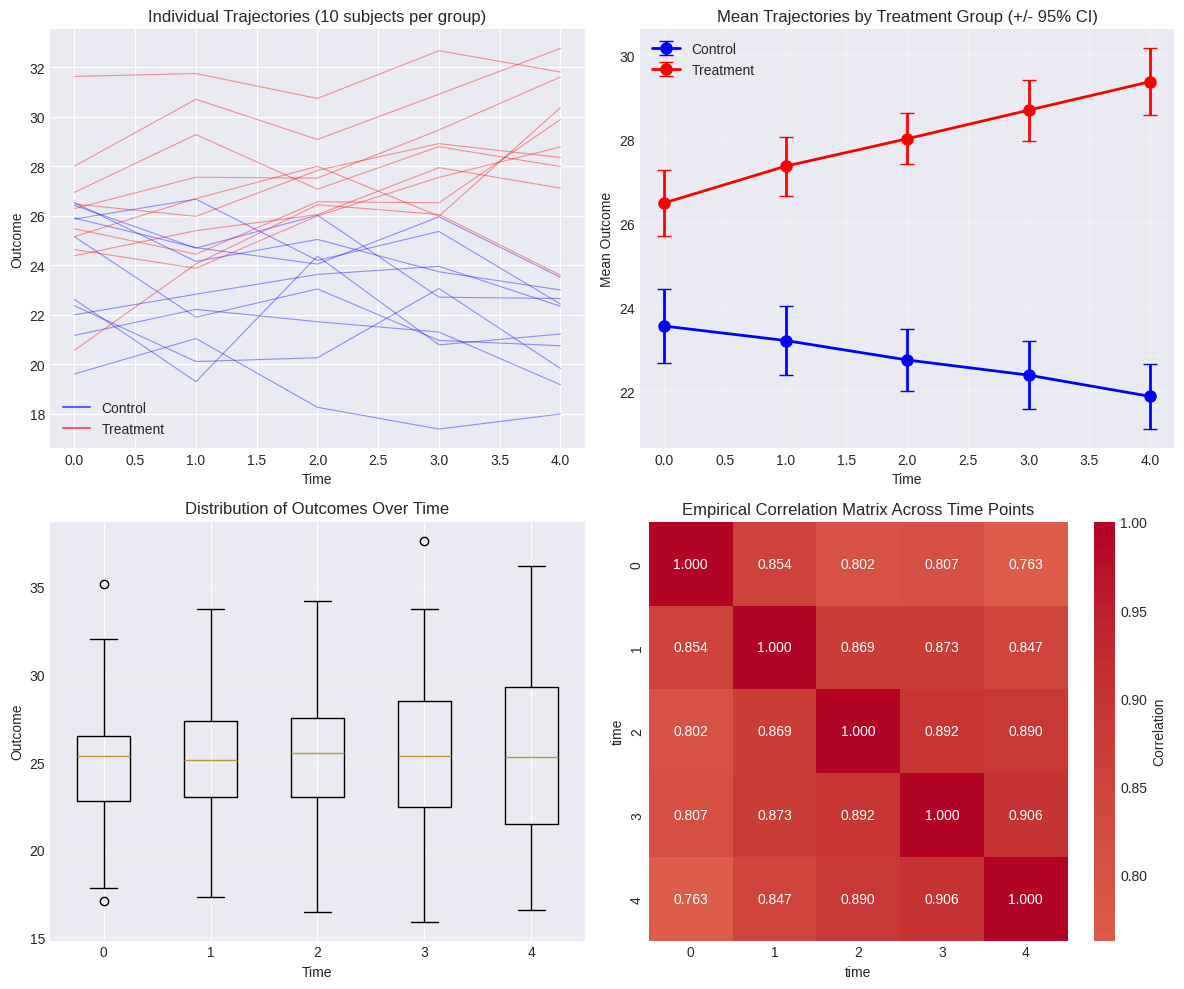



3. MODEL DEFINITION AND FITTING
------------------------------

Fitting GEE models with different correlation structures...
Model formula: outcome ~ treatment + time + treatment_time + age + gender
Note: Intercept is automatically included when using from_formula

Independence correlation structure:
  Converged: True
  Number of iterations: 1
  Scale parameter: 4.4152

Exchangeable correlation structure:
  Converged: True
  Number of iterations: 1
  Scale parameter: 4.4152
  Correlation parameter: 0.6077

Autoregressive correlation structure:
  Converged: True
  Number of iterations: 11
  Scale parameter: 4.4259
  Correlation parameter: 0.7480

Unstructured correlation structure:
  Converged: True
  Number of iterations: 6
  Scale parameter: 4.4167
  Correlation matrix:
     1.0000  0.6882  0.6306  0.6753  0.5819
     0.6882  1.0000  0.6211  0.6527  0.5522
     0.6306  0.6211  1.0000  0.6024  0.5284
     0.6753  0.6527  0.6024  1.0000  0.5899
     0.5819  0.5522  0.5284  0.5899  1.00

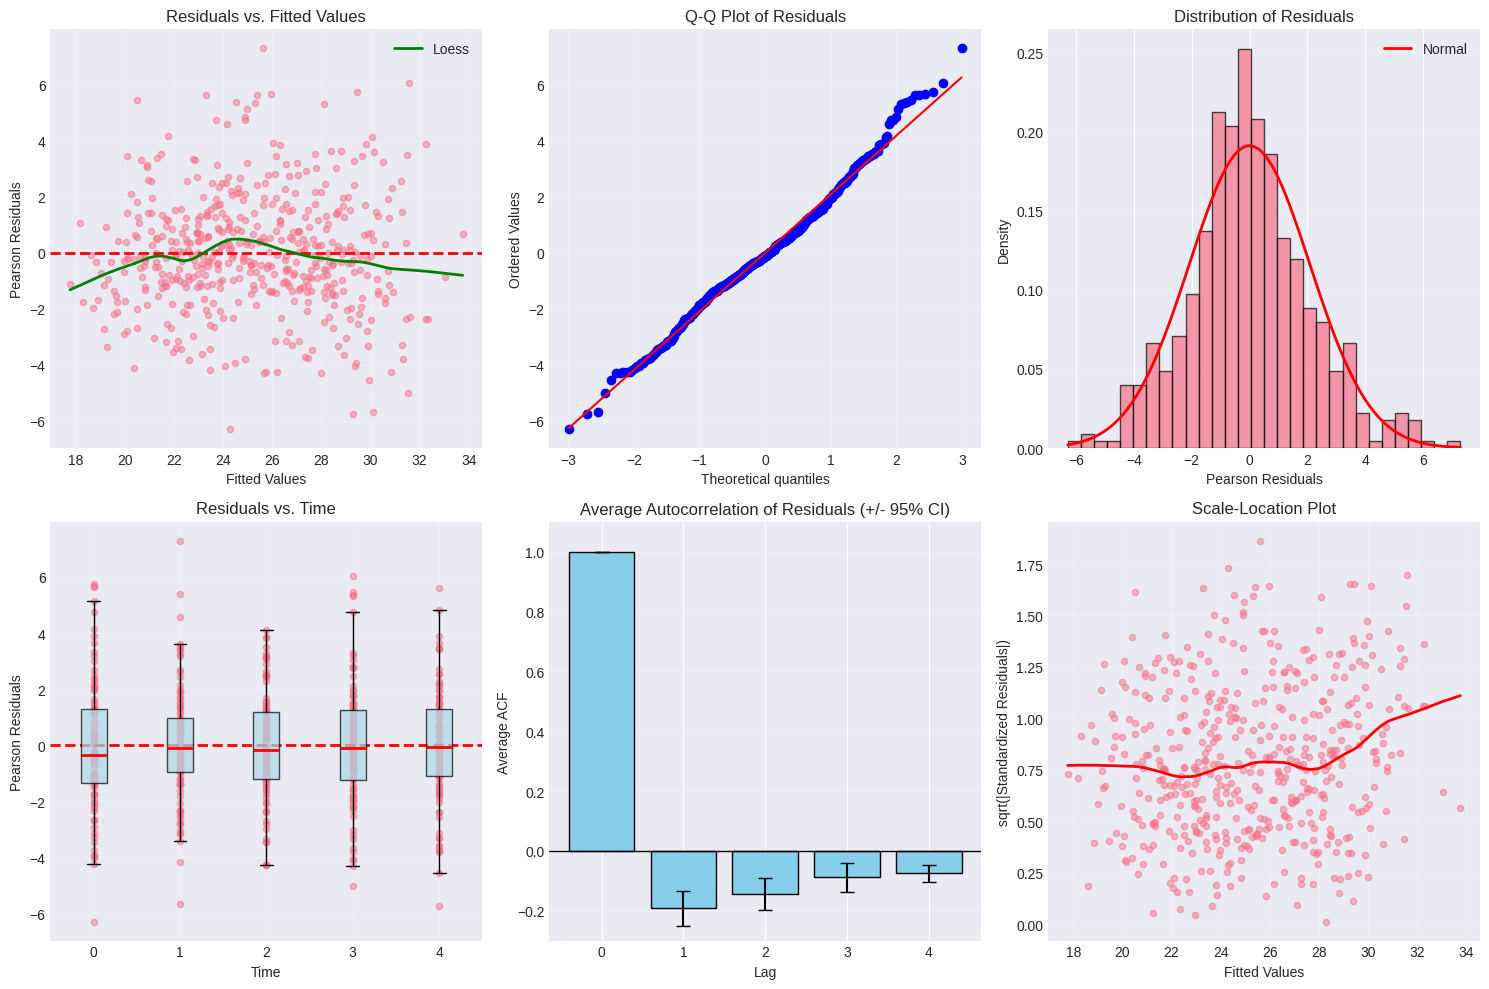



5. RESULTS EVALUATION
------------------------------

Model Comparison using QIC (Quasi-likelihood Information Criterion):
----------------------------------------------------------------------------------------------------
Correlation     QIC          Scale      Treatment    Time         Interaction 
----------------------------------------------------------------------------------------------------
Independence    522.23       4.415      3.054        -0.417       1.127       
Exchangeable    522.23       4.415      3.054        -0.417       1.127       
Autoregressive  524.54       4.426      3.020        -0.418       1.138       
Unstructured    521.61       4.417      3.053        -0.412       1.129       

Best model by QIC: Unstructured


Detailed Results (Main Model):
                               GEE Regression Results                              
Dep. Variable:                     outcome   No. Observations:                  500
Model:                                 GEE  

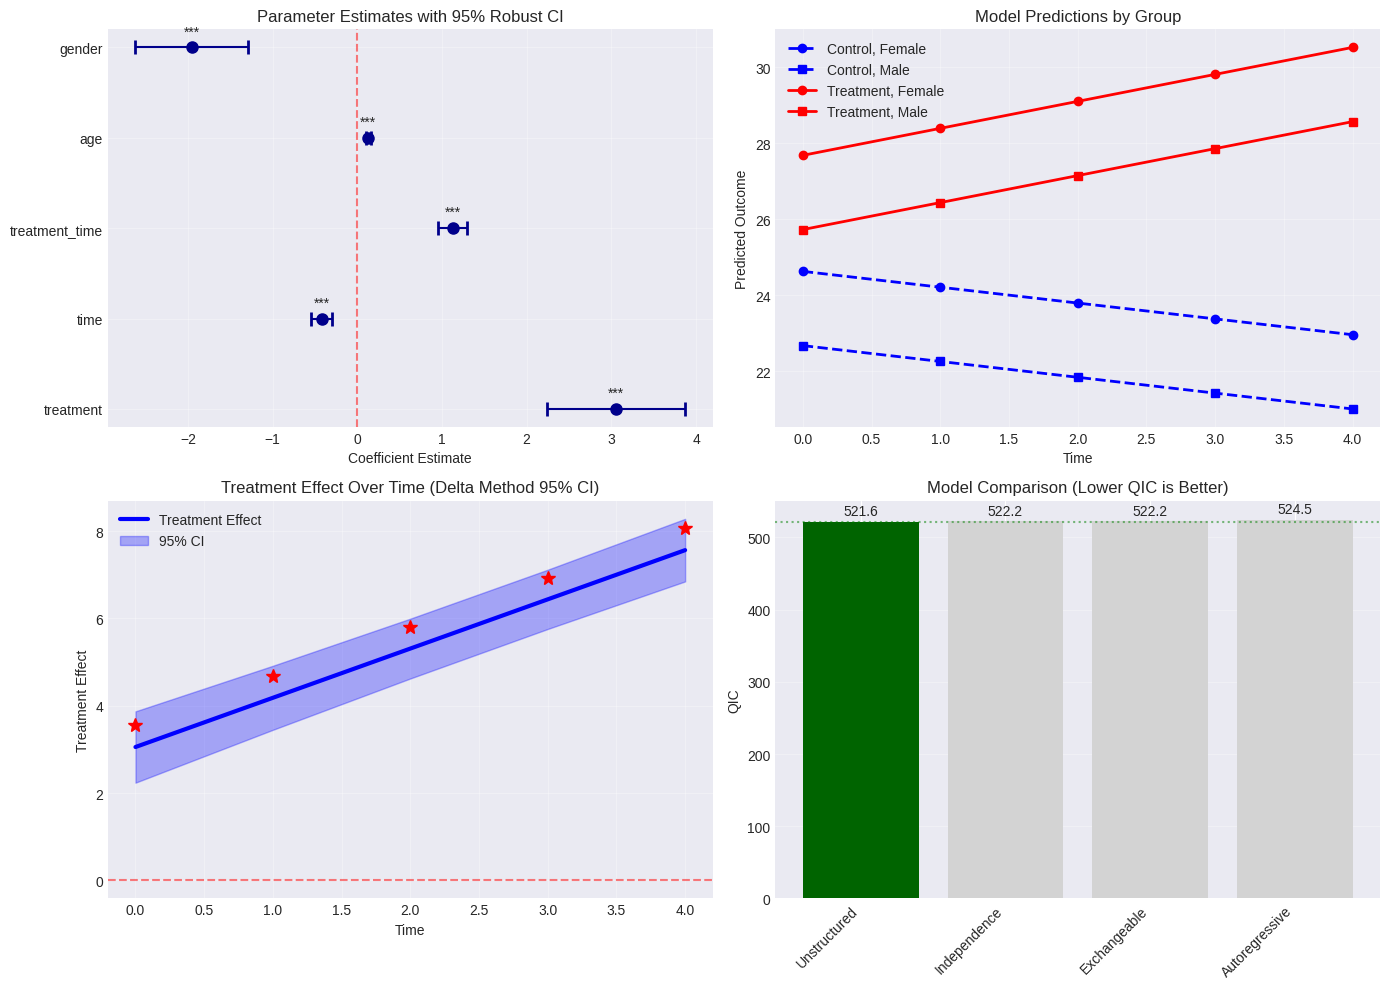



7. INTERPRETATION AND CONCLUSIONS
------------------------------


INTERPRETATION AND CONCLUSIONS
------------------------------

Key Findings:
1. Main treatment effect at baseline (time=0): 3.054 (SE: 0.417, p=0.0000)
2. Treatment-time interaction: 1.127 (SE: 0.089, p=0.0000)

   -> Significant interaction indicates treatment effect changes over time
   -> Treatment effect increases over time (cumulative benefit)

3. Estimated treatment effects at each time point:
   ----------------------------------------
   Time | Effect |    95% CI    | Sig
   ----------------------------------------
      0 |   3.05 | [  2.24,   3.87] | *
      1 |   4.18 | [  3.45,   4.91] | *
      2 |   5.31 | [  4.62,   5.99] | *
      3 |   6.44 | [  5.76,   7.11] | *
      4 |   7.56 | [  6.85,   8.28] | *

4. Model diagnostics summary:
   -> Residuals appear approximately normally distributed
   -> No strong patterns in residuals vs. fitted values
   -> Some mild autocorrelation present (expected in long

In [8]:
# Main execution
if __name__ == "__main__":
    # Create and run the workflow
    workflow = GEEWorkflow(
        n_subjects=100,
        n_times=5,
        correlation=0.6,
        random_seed=42
    )

    workflow.run_complete_analysis()